In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_320.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_086.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_241.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_036.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_127.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_124.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_084.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_181.jpg
/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset/val/Sahiwal/Sahiwal_278.jpg
/kaggle/in

Starting training on cuda for 300 epochs...

Epoch 01/300
  Train -> Loss: 0.6424 | Acc: 0.7361
  Val   -> Loss: 0.8298   | Acc: 0.6953 | Recall: 0.7527 | F1: 0.6989 | IoU: 0.5731
--------------------------------------------------------------------------------
Epoch 02/300
  Train -> Loss: 0.3103 | Acc: 0.8714
  Val   -> Loss: 0.2545   | Acc: 0.8896 | Recall: 0.9054 | F1: 0.9056 | IoU: 0.8310
--------------------------------------------------------------------------------
Epoch 03/300
  Train -> Loss: 0.2500 | Acc: 0.9105
  Val   -> Loss: 0.2354   | Acc: 0.9202 | Recall: 0.9404 | F1: 0.9286 | IoU: 0.8678
--------------------------------------------------------------------------------
Epoch 04/300
  Train -> Loss: 0.1927 | Acc: 0.9264
  Val   -> Loss: 0.2218   | Acc: 0.9427 | Recall: 0.9574 | F1: 0.9517 | IoU: 0.9092
--------------------------------------------------------------------------------
Epoch 05/300
  Train -> Loss: 0.2040 | Acc: 0.9151
  Val   -> Loss: 0.1809   | Acc: 0.9284 

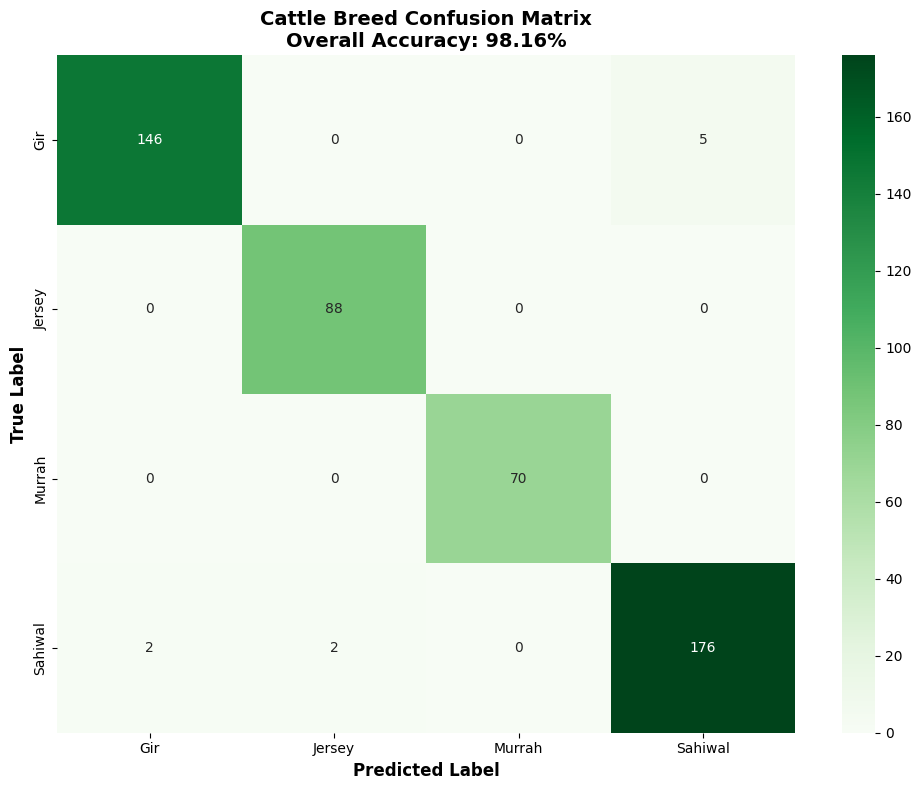

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report, jaccard_score

# 1. Hyperparameters & Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 300

# 2. Data Loading & Augmentation
dataset_dir = '/kaggle/input/datasets/annujkumar/breed-classification/combined_livestock_dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_db = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_db = datasets.ImageFolder(root=val_dir, transform=val_transform)
class_names = train_db.classes # ['Gir', 'Jersey', 'Murrah', 'Sahiwal']

train_loader = DataLoader(train_db, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_db, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 3. Model Setup
model = models.mobilenet_v2(weights='DEFAULT')
for param in model.parameters():
    param.requires_grad = False
for param in model.features[-4:].parameters():
    param.requires_grad = True

model.classifier[1] = nn.Linear(model.last_channel, 4)
model.to(DEVICE)

# 4. Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 5. Training Loop with Full Metrics
best_acc = 0.0

print(f"Starting training on {DEVICE} for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    train_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)

    # Calculate Training Metrics
    epoch_train_loss = running_loss / len(train_db)
    epoch_train_acc = train_corrects.double() / len(train_db)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate Validation Metrics
    epoch_val_loss = val_loss / len(val_db)
    epoch_val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    
    # Advanced Metrics (Macro average treats all classes equally regardless of imbalance)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_iou = jaccard_score(all_labels, all_preds, average='macro', zero_division=0) # Equivalent to Classification IoU
    
    # Formatted Print Statement
    print(f"Epoch {epoch+1:02d}/{EPOCHS}")
    print(f"  Train -> Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"  Val   -> Loss: {epoch_val_loss:.4f}   | Acc: {epoch_val_acc:.4f} | Recall: {epoch_recall:.4f} | F1: {epoch_f1:.4f} | IoU: {epoch_iou:.4f}")
    print("-" * 80)

    scheduler.step()

    # Save Best Model
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_cattle_model.pth")
        final_preds = all_preds
        final_labels = all_labels

# 6. Final Confusion Matrix & Report
print("\n" + "="*40)
print("FINAL EVALUATION REPORT (BEST EPOCH)")
print("="*40)
print(classification_report(final_labels, final_preds, target_names=class_names, zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Cattle Breed Confusion Matrix\nOverall Accuracy: {best_acc:.2%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()